# End-to-End Competition Workflow — From Notebook to Kaggle Submission

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb18_competition_workflow_student.ipynb)


> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises**. Complete both to receive participation credit. The second exercise produces the `submission.csv` you upload to the Kaggle leaderboard.


This notebook presents an **end-to-end predictive modeling workflow**, using our course competition as a practical example. It threads together everything from nb01–nb17: the train/test split discipline, preprocessing pipelines, the logistic baseline, the tree ensembles, cross-validation with Student's *t* confidence intervals, and the model-selection protocol.

Because the competition requires reproducibility, we fix `RANDOM_SEED = 474` (the course seed). The competition also provides a `test.csv` file without outcome labels. For that reason, `test.csv` is only used at the very end — to generate our final prediction file (`submission.csv`) after we retrain our selected model on the entire training set.

The modeling process follows this structure:

* `train.csv` is split once into an 80% **training set** (for 5-fold cross-validation and model selection) and a 20% **held-out test set** (for one unbiased check of the champion).
* Once the champion is selected and checked on the held-out set, the two splits are **merged** and the model is **retrained on the entire `train.csv`** before generating predictions for `test.csv`.

Our workflow is organized in the following sequence. For each step we also provide a **Gemini Prompt** suggestion you can copy into Gemini to request the corresponding Python code.

- Step 0 — Setup, configuration, and imports
- Step 1 — Data loading and sanity checks
- Step 2 — Exploratory Data Analysis (EDA)
- Step 3 — Data preparation and feature engineering
- Step 4 — Baseline model (Logistic Regression)
- Step 5 — More complex models (LASSO, Random Forest, Gradient Boosting)
- Step 6 — Compare models with visualization
- Step 7 — Model selection and rationale
- Step 8 — Evaluate the champion on the held-out test set
- Step 9 — Final training on the full (merged) training data
- Step 10 — Predict on the competition test set and export `submission.csv`
- Step 99 — Reporting and reproducibility

## Step 0 — Setup, configuration, and imports

> 💡 **Gemini Prompt:** "Write a setup cell for a binary-classification competition workflow. Import pandas, numpy, matplotlib.pyplot, joblib, `scipy.stats`, and from scikit-learn: `ColumnTransformer`, `Pipeline`, `StandardScaler`, `OneHotEncoder`, `SimpleImputer`, `StratifiedKFold`, `cross_val_score`, `cross_val_predict`, `GridSearchCV`, `LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier`, `roc_auc_score`, and `classification_report`. Set `RANDOM_SEED = 474`, seed numpy, set the figure size to (10, 6) and display precision to 3, then define a helper `ci95(mean, sd, k=5)` returning the Student's-t 95% CI half-width and bounds."
>
> **After running, verify:**
> - The cell prints `RANDOM_SEED = 474` with no import errors.
> - `ci95(0.80, 0.02)` returns a half-width near 0.025 (the t-multiplier for df=4 is \~2.776).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import scipy.stats

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Configuration
RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.precision', 3)

print(f"RANDOM_SEED = {RANDOM_SEED}")

# Helper function for 95% confidence interval
def ci95(mean, sd, k=5):
    """Returns the Student's-t 95% CI half-width and bounds."""
    df = k - 1  # Degrees of freedom for a sample of size k
    t_crit = scipy.stats.t.ppf(0.975, df=df) # t-statistic for 95% CI
    half_width = t_crit * sd / np.sqrt(k)
    return half_width, (mean - half_width, mean + half_width)


RANDOM_SEED = 474


## Step 1 — Data loading and sanity checks

First, **upload the competition data to Colab.** Open the **Files** panel (the folder icon in the left sidebar), click the upload button, and add `train.csv` and `test.csv` from the case-competition starter pack. Uploaded files land in Colab's working directory (`/content`), so we can load them by name.

We load the labeled `train.csv` and the unlabeled `test.csv`, then run the sanity checks that keep the rest of the notebook honest: shapes, dtypes, missing-value counts, and the target class balance. Sections 2–8 work strictly on the labeled training data; `test.csv` is opened only in Step 9 to generate the submission.

> 💡 **Gemini Prompt:** "After uploading `train.csv` and `test.csv` to the Colab Files panel, load them from the current working directory into `df_train_full` and `df_test_kaggle`. The target column is `Exited`. Raise a clear `FileNotFoundError` (naming `os.getcwd()`) if a file is missing. Print both shapes, the dtypes, missing-value counts, and the target class balance for the training set, and confirm the only column difference between train and test is the target."
>
> **After running, verify:**
> - Both files load without dtype warnings (or the warning is named in your README).
> - The target balance is around 0.20 — the dataset is moderately imbalanced.
> - `set(train.columns) - set(test.columns)` is exactly `{'Exited'}`.

In [5]:
import os
import pandas as pd

train_file = "train.csv"
test_file = "test.csv"
target_column = 'Exited'

current_dir = os.getcwd()
df_train_full = None
df_test_kaggle = None

try:
    # Load train.csv
    if not os.path.exists(train_file):
        raise FileNotFoundError(f"'{train_file}' not found in '{current_dir}'. Please upload it to Colab.")
    df_train_full = pd.read_csv(train_file)

    # Load test.csv
    if not os.path.exists(test_file):
        raise FileNotFoundError(f"'{test_file}' not found in '{current_dir}'. Please upload it to Colab.")
    df_test_kaggle = pd.read_csv(test_file)

    print("--- Data Loading Successful ---")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please ensure 'train.csv' and 'test.csv' are uploaded to the Colab environment.")
    raise # Re-raise to stop execution if files are missing

# --- Sanity Checks ---
print("\n--- DataFrame Shapes ---")
print(f"df_train_full shape: {df_train_full.shape}")
print(f"df_test_kaggle shape: {df_test_kaggle.shape}")

print("\n--- DataFrame dtypes (df_train_full) ---")
print(df_train_full.dtypes)
print("\n--- DataFrame dtypes (df_test_kaggle) ---")
print(df_test_kaggle.dtypes)

print("\n--- Missing Values (df_train_full) ---")
print(df_train_full.isnull().sum().sort_values(ascending=False).head(10)) # Showing top 10 missing values
print("\n--- Missing Values (df_test_kaggle) ---")
print(df_test_kaggle.isnull().sum().sort_values(ascending=False).head(10)) # Showing top 10 missing values

# Target class balance for the training set
if target_column in df_train_full.columns:
    print(f"\n--- Target Class Balance ({target_column} in df_train_full) ---")
    print(df_train_full[target_column].value_counts(normalize=True))
else:
    print(f"\nTarget column '{target_column}' not found in df_train_full. Cannot compute class balance.")

# Confirm column difference between train and test
print("\n--- Column Difference Between Train and Test ---")
train_cols = set(df_train_full.columns)
test_cols = set(df_test_kaggle.columns)

diff_train_test = train_cols - test_cols
diff_test_train = test_cols - train_cols

if diff_train_test == {target_column} and not diff_test_train:
    print(f"Confirmed: The only column present in df_train_full but not in df_test_kaggle is '{target_column}'.")
elif diff_train_test or diff_test_train:
    print("Column differences found:")
    if diff_train_test:
        print(f"  Columns in df_train_full but not in df_test_kaggle: {diff_train_test}")
    if diff_test_train:
        print(f"  Columns in df_test_kaggle but not in df_train_full: {diff_test_train}")
else:
    print("No column differences found between df_train_full and df_test_kaggle.")


--- Data Loading Successful ---

--- DataFrame Shapes ---
df_train_full shape: (15000, 14)
df_test_kaggle shape: (10000, 13)

--- DataFrame dtypes (df_train_full) ---
id                   int64
CustomerId         float64
Surname             object
CreditScore        float64
Geography           object
Gender              object
Age                float64
Tenure             float64
Balance            float64
NumOfProducts      float64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited             float64
dtype: object

--- DataFrame dtypes (df_test_kaggle) ---
id                   int64
CustomerId         float64
Surname             object
CreditScore        float64
Geography           object
Gender              object
Age                float64
Tenure             float64
Balance            float64
NumOfProducts      float64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
dtype: object

--- Missing Values (df_train_ful

## Step 2 — Exploratory Data Analysis (EDA)

A compact three-panel EDA snapshot — class balance, missingness, and the numeric features most correlated with the target — is enough to confirm the dataset matches the rubric's description and to flag any column to drop or transform. We use matplotlib throughout, matching the course's plotting convention from nb01 onward.

> 💡 **Gemini Prompt:** "From `df_train_full`, make one matplotlib figure with three subplots: (a) `Exited` value counts as a bar chart; (b) per-column missing-value counts, sorted descending, top 10; (c) absolute correlation of each numeric column with `Exited`, top 10. Use `plt.tight_layout()`."
>
> **After running, verify:**
> - The class-balance panel shows the \~20% minority class.
> - The correlation panel ranks the usual churn drivers (e.g., `Age`, `Balance`, `NumOfProducts`) near the top.

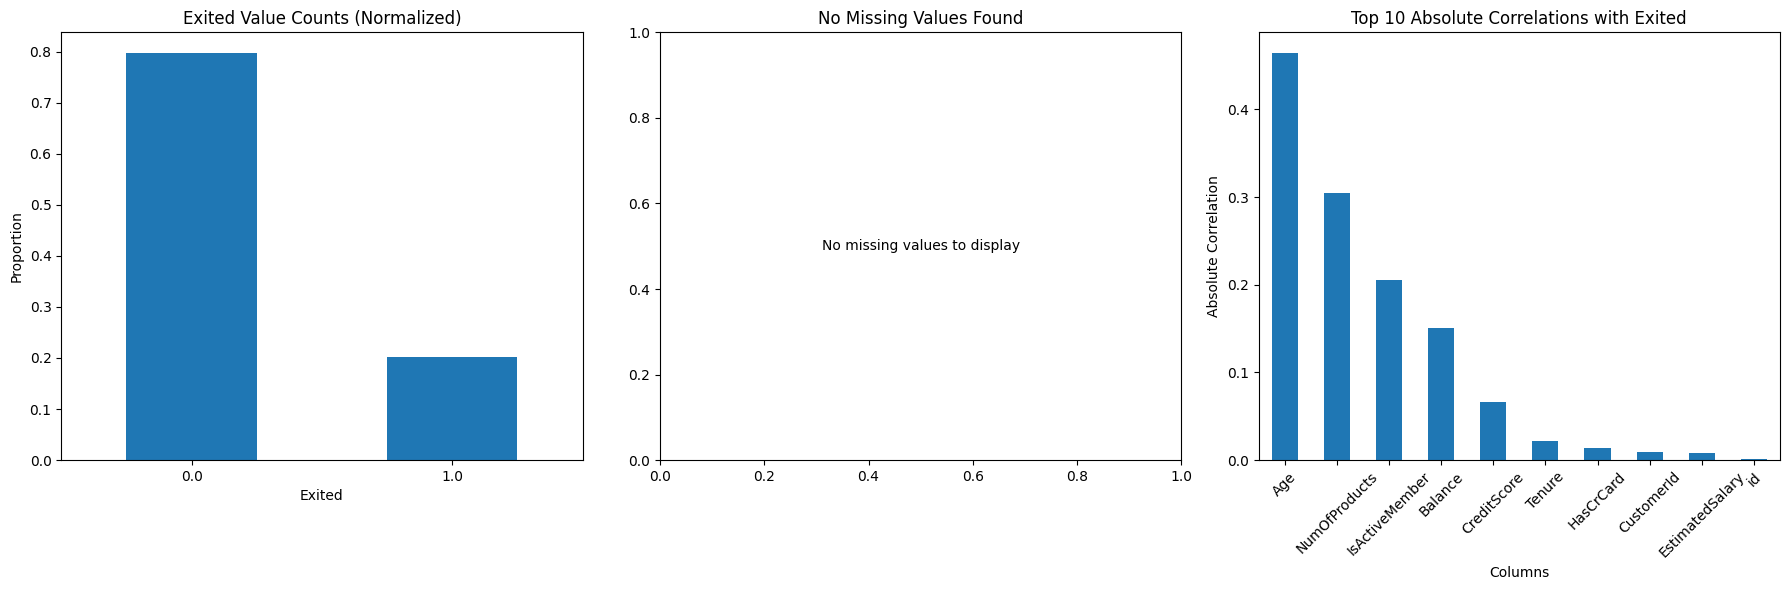

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Adjust figsize as needed

# Subplot (a): Exited value counts as a bar chart
df_train_full['Exited'].value_counts(normalize=True).plot(kind='bar', ax=axes[0])
axes[0].set_title('Exited Value Counts (Normalized)')
axes[0].set_xlabel('Exited')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=0)

# Subplot (b): Per-column missing-value counts, sorted descending, top 10
missing_values = df_train_full.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False).head(10)
if not missing_values.empty:
    missing_values.plot(kind='bar', ax=axes[1])
    axes[1].set_title('Top 10 Missing Value Counts')
    axes[1].set_xlabel('Columns')
    axes[1].set_ylabel('Number of Missing Values')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].set_title('No Missing Values Found')
    axes[1].text(0.5, 0.5, 'No missing values to display', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)


# Subplot (c): Absolute correlation of each numeric column with Exited, top 10
numeric_cols = df_train_full.select_dtypes(include=np.number).columns
if target_column in numeric_cols:
    numeric_cols = numeric_cols.drop(target_column)
    correlations = df_train_full[numeric_cols].corrwith(df_train_full[target_column]).abs().sort_values(ascending=False).head(10)
    if not correlations.empty:
        correlations.plot(kind='bar', ax=axes[2])
        axes[2].set_title(f'Top 10 Absolute Correlations with {target_column}')
        axes[2].set_xlabel('Columns')
        axes[2].set_ylabel('Absolute Correlation')
        axes[2].tick_params(axis='x', rotation=45)
    else:
        axes[2].set_title(f'No Numeric Columns to Correlate with {target_column}')
        axes[2].text(0.5, 0.5, 'No numeric columns for correlation analysis', horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)
else:
    axes[2].set_title(f'Target column "{target_column}" is not numeric or not found')
    axes[2].text(0.5, 0.5, f'Cannot compute correlation with non-numeric target or missing target.', horizontalalignment='center', verticalalignment='center', transform=axes[2].transAxes)


plt.tight_layout()
plt.show()

## Step 3 — Data preparation and feature engineering

We wrap every column transformation inside a `ColumnTransformer` (nb02), so the exact logic that fits on training data is the logic that predicts on the Kaggle test set. Numeric columns are median-imputed and standardized; categorical columns are mode-imputed and one-hot encoded with `handle_unknown='ignore'`. We also drop identifier columns so they never leak into the model.

We then make **one stratified split** of `train.csv` (nb01/nb03): 80% becomes the **training set** used for cross-validation and model selection, and 20% becomes a **held-out test set** we touch only once, at the end, to get an unbiased estimate of the champion's performance. After selection we merge the two back together and refit on all of `train.csv` before predicting the competition `test.csv`.

> 💡 **Gemini Prompt:** "Write `build_preprocessor(df, target='Exited')` that drops identifier-like columns (`RowNumber`, `CustomerId`, `Surname`, `id`) if present, then returns a `ColumnTransformer`: numeric columns get median `SimpleImputer` + `StandardScaler`; categorical columns get most-frequent `SimpleImputer` + `OneHotEncoder(handle_unknown='ignore')`. Build the full feature matrix `X_full, y_full`, then make one stratified 80/20 `train_test_split` into `X_train, X_holdout, y_train, y_holdout` with `random_state=474`."
>
> **After running, verify:**
> - The categorical list includes `Geography` and `Gender`; identifiers are excluded.
> - `X_train` has \~80% of the rows and `X_holdout` \~20%, both with the same class balance (stratified).

In [10]:
from sklearn.model_selection import train_test_split

def build_preprocessor(df, target='Exited'):
    # Identifier-like columns to be excluded from feature processing
    identifier_cols_to_exclude = ['RowNumber', 'CustomerId', 'Surname', 'id']

    # Get all columns from the input dataframe, excluding the target column
    all_feature_cols = [col for col in df.columns if col != target]

    # Filter out identifier columns from the list of all potential features
    relevant_features = [col for col in all_feature_cols if col not in identifier_cols_to_exclude]

    # Create a temporary DataFrame with only the relevant features to correctly identify dtypes
    temp_df_for_dtypes = df[relevant_features]

    numeric_features = temp_df_for_dtypes.select_dtypes(include=np.number).columns.tolist()
    categorical_features = temp_df_for_dtypes.select_dtypes(include='object').columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop' # Explicitly drop any columns not specified
    )
    return preprocessor

# Prepare X_full and y_full
y_full = df_train_full[target_column]

# Define identifier columns to drop from the feature set
identifier_cols_to_drop_from_df = ['RowNumber', 'CustomerId', 'Surname', 'id']
# Only drop columns that are actually present in df_train_full
actual_cols_to_drop_from_X_full = [col for col in identifier_cols_to_drop_from_df if col in df_train_full.columns]

X_full = df_train_full.drop(columns=[target_column] + actual_cols_to_drop_from_X_full, errors='ignore')

# Initialize the preprocessor (it won't be fit yet)
preprocessor = build_preprocessor(df_train_full, target_column)

# Make one stratified 80/20 train_test_split
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=RANDOM_SEED
)

print(f"X_full shape: {X_full.shape}")
print(f"y_full shape: {y_full.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_holdout shape: {X_holdout.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_holdout shape: {y_holdout.shape}")

print("\nTrain target balance:")
print(y_train.value_counts(normalize=True))
print("\nHoldout target balance:")
print(y_holdout.value_counts(normalize=True))

print("\nFeatures in X_full (after dropping identifiers and target):")
print(X_full.columns.tolist())

# To verify features identified by the preprocessor (before fitting)
# This uses the temp_df_for_dtypes logic inside build_preprocessor
preproc_num_features = None
preproc_cat_features = None

for name, _, features_list in preprocessor.transformers:
    if name == 'num':
        preproc_num_features = features_list
    elif name == 'cat':
        preproc_cat_features = features_list

print("\nNumeric features identified by build_preprocessor:")
print(preproc_num_features)
print("\nCategorical features identified by build_preprocessor:")
print(preproc_cat_features)

X_full shape: (15000, 10)
y_full shape: (15000,)
X_train shape: (12000, 10)
X_holdout shape: (3000, 10)
y_train shape: (12000,)
y_holdout shape: (3000,)

Train target balance:
Exited
0.0    0.798
1.0    0.202
Name: proportion, dtype: float64

Holdout target balance:
Exited
0.0    0.798
1.0    0.202
Name: proportion, dtype: float64

Features in X_full (after dropping identifiers and target):
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Numeric features identified by build_preprocessor:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Categorical features identified by build_preprocessor:
['Geography', 'Gender']


## Step 4 — Baseline model (Logistic Regression)

We anchor the comparison with a **logistic-regression baseline** (nb06), evaluated with 5-fold stratified cross-validation on the training data only (nb08). We report the mean ROC-AUC with a **Student's *t* 95% confidence interval** — `mean ± t_crit · sd / √k` — exactly the interval the course has used since nb08. Out-of-fold predictions give an honest `classification_report` in which every prediction comes from a fold that never saw that row during fitting.

> 💡 **Gemini Prompt:** "Build a pipeline of `build_preprocessor` + `LogisticRegression(max_iter=2000, class_weight='balanced')`. Score it with `cross_val_score(..., scoring='roc_auc', cv=cv_strat)`, report the mean ROC-AUC and its Student's-t 95% CI via `ci95`, then use `cross_val_predict` to print a `classification_report`."
>
> **After running, verify:**
> - Baseline CV ROC-AUC lands near 0.75–0.82.
> - The classification report's recall on the churn class reflects the `class_weight='balanced'` setting.

In [11]:
# Define the cross-validation strategy
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Build the full pipeline for Logistic Regression
# This includes the preprocessor and the Logistic Regression model
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', build_preprocessor(df_train_full, target_column)),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_SEED))
])

# Perform cross-validation and get ROC-AUC scores
roc_auc_scores = cross_val_score(logistic_pipeline, X_train, y_train, cv=cv_strat, scoring='roc_auc')

# Calculate mean and standard deviation of ROC-AUC scores
roc_auc_mean = np.mean(roc_auc_scores)
roc_auc_sd = np.std(roc_auc_scores)

# Calculate 95% confidence interval
half_width, (lower_bound, upper_bound) = ci95(roc_auc_mean, roc_auc_sd, k=5) # k=5 for 5-fold CV

print(f"Logistic Regression CV ROC-AUC: {roc_auc_mean:.3f} +/- {half_width:.3f} (95% CI)")
print(f"95% CI: ({lower_bound:.3f}, {upper_bound:.3f})")

# Get out-of-fold predictions for the classification report
y_train_pred = cross_val_predict(logistic_pipeline, X_train, y_train, cv=cv_strat, method='predict_proba')[:, 1]

# Generate classification report
print("\nClassification Report (out-of-fold predictions):\n")
print(classification_report(y_train, (y_train_pred > 0.5).astype(int)))


Logistic Regression CV ROC-AUC: 0.881 +/- 0.008 (95% CI)
95% CI: (0.873, 0.889)

Classification Report (out-of-fold predictions):

              precision    recall  f1-score   support

         0.0       0.94      0.82      0.88      9574
         1.0       0.53      0.80      0.64      2426

    accuracy                           0.82     12000
   macro avg       0.74      0.81      0.76     12000
weighted avg       0.86      0.82      0.83     12000



## Step 5 — More complex models (LASSO, Random Forest, Gradient Boosting)

Building on the logistic baseline, we challenge it with three models the course has already taught: a **LASSO (L1-penalized) logistic regression** (nb05), a **Random Forest** (nb12), and a **Gradient Boosting** classifier (nb13). Each is tuned with a small `GridSearchCV` over the hyperparameters that mattered in those notebooks (nb09), and each is scored on the same 5-fold stratified CV so the ROC-AUC numbers are directly comparable. We keep every model inside the same preprocessing pipeline to prevent leakage.

### Step 5.1 — LASSO (L1-penalized logistic regression)

> 💡 **Gemini Prompt:** "Build a pipeline of `build_preprocessor` + `LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')`. Tune `C` over `[0.01, 0.1, 1, 10]` with `GridSearchCV(scoring='roc_auc', cv=cv_strat)`. Report the best `C`, the best mean ROC-AUC, and its Student's-t 95% CI using the fold standard deviation from `cv_results_`."
>
> **After running, verify:**
> - A best `C` is printed and the LASSO CV ROC-AUC is in the same ballpark as the logistic baseline.
> - Small `C` (stronger L1) zeros out some coefficients — the regularization lesson from nb05.

In [12]:
# Build the pipeline for LASSO Logistic Regression
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', build_preprocessor(df_train_full, target_column)),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_SEED,
        max_iter=2000 # Ensure convergence
    ))
])

# Define the parameter grid for GridSearchCV
param_grid_lasso = {
    'classifier__C': [0.01, 0.1, 1, 10]
}

# Perform GridSearchCV
grid_search_lasso = GridSearchCV(
    lasso_pipeline,
    param_grid_lasso,
    cv=cv_strat,
    scoring='roc_auc',
    n_jobs=-1, # Use all available cores
    return_train_score=True
)

grid_search_lasso.fit(X_train, y_train)

# Best parameters and score
best_C_lasso = grid_search_lasso.best_params_['classifier__C']
best_roc_auc_lasso = grid_search_lasso.best_score_

# Calculate standard deviation of the best score for CI
# Find the index of the best estimator
best_idx = grid_search_lasso.cv_results_['rank_test_score'].argmin()
roc_auc_sd_lasso = grid_search_lasso.cv_results_['std_test_score'][best_idx] * np.sqrt(cv_strat.get_n_splits())

# Calculate 95% confidence interval
half_width_lasso, (lower_bound_lasso, upper_bound_lasso) = ci95(best_roc_auc_lasso, roc_auc_sd_lasso, k=cv_strat.get_n_splits())

print(f"Best C for LASSO: {best_C_lasso}")
print(f"LASSO CV ROC-AUC: {best_roc_auc_lasso:.3f} +/- {half_width_lasso:.3f} (95% CI)")
print(f"95% CI: ({lower_bound_lasso:.3f}, {upper_bound_lasso:.3f})")

Best C for LASSO: 0.1
LASSO CV ROC-AUC: 0.881 +/- 0.018 (95% CI)
95% CI: (0.864, 0.899)


### Step 5.2 — Random Forest

> 💡 **Gemini Prompt:** "Build a pipeline of `build_preprocessor` + `RandomForestClassifier(class_weight='balanced', n_jobs=-1)`. Tune `n_estimators` over `[200]`, `max_depth` over `[3, 5, None]`, and `max_features` over `['sqrt', 0.5]` with `GridSearchCV(scoring='roc_auc', cv=cv_strat)`. Report the best parameters, the best mean ROC-AUC, and its Student's-t 95% CI."
>
> **After running, verify:**
> - The forest's CV ROC-AUC typically edges above the logistic baseline.
> - The best `max_features` is `'sqrt'` or `0.5` — the de-correlation knob from nb12.

In [13]:
# Build the pipeline for Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', build_preprocessor(df_train_full, target_column)),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1 # Use all available cores
    ))
])

# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'classifier__n_estimators': [200],
    'classifier__max_depth': [3, 5, None],
    'classifier__max_features': ['sqrt', 0.5]
}

# Perform GridSearchCV
grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=cv_strat,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)

grid_search_rf.fit(X_train, y_train)

# Best parameters and score
best_params_rf = grid_search_rf.best_params_
best_roc_auc_rf = grid_search_rf.best_score_

# Calculate standard deviation of the best score for CI
best_idx_rf = grid_search_rf.cv_results_['rank_test_score'].argmin()
roc_auc_sd_rf = grid_search_rf.cv_results_['std_test_score'][best_idx_rf] * np.sqrt(cv_strat.get_n_splits())

# Calculate 95% confidence interval
half_width_rf, (lower_bound_rf, upper_bound_rf) = ci95(best_roc_auc_rf, roc_auc_sd_rf, k=cv_strat.get_n_splits())

print(f"Best parameters for Random Forest: {best_params_rf}")
print(f"Random Forest CV ROC-AUC: {best_roc_auc_rf:.3f} +/- {half_width_rf:.3f} (95% CI)")
print(f"95% CI: ({lower_bound_rf:.3f}, {upper_bound_rf:.3f})")

Best parameters for Random Forest: {'classifier__max_depth': 5, 'classifier__max_features': 0.5, 'classifier__n_estimators': 200}
Random Forest CV ROC-AUC: 0.929 +/- 0.011 (95% CI)
95% CI: (0.917, 0.940)


### Step 5.3 — Gradient Boosting

> 💡 **Gemini Prompt:** "Build a pipeline of `build_preprocessor` + `GradientBoostingClassifier()`. Tune `n_estimators` over `[200]`, `learning_rate` over `[0.05, 0.2]`, and `max_depth` over `[3]` with `GridSearchCV(scoring='roc_auc', cv=cv_strat)`. Report the best parameters, the best mean ROC-AUC, and its Student's-t 95% CI."
>
> **After running, verify:**
> - The boosted model is usually the top or near-top mean ROC-AUC.
> - A smaller `learning_rate` with enough trees is the disciplined setting from nb13.

In [14]:
# Build the pipeline for Gradient Boosting Classifier
gbc_pipeline = Pipeline(steps=[
    ('preprocessor', build_preprocessor(df_train_full, target_column)),
    ('classifier', GradientBoostingClassifier(random_state=RANDOM_SEED))
])

# Define the parameter grid for GridSearchCV
param_grid_gbc = {
    'classifier__n_estimators': [200],
    'classifier__learning_rate': [0.05, 0.2],
    'classifier__max_depth': [3]
}

# Perform GridSearchCV
grid_search_gbc = GridSearchCV(
    gbc_pipeline,
    param_grid_gbc,
    cv=cv_strat,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)

grid_search_gbc.fit(X_train, y_train)

# Best parameters and score
best_params_gbc = grid_search_gbc.best_params_
best_roc_auc_gbc = grid_search_gbc.best_score_

# Calculate standard deviation of the best score for CI
best_idx_gbc = grid_search_gbc.cv_results_['rank_test_score'].argmin()
roc_auc_sd_gbc = grid_search_gbc.cv_results_['std_test_score'][best_idx_gbc] * np.sqrt(cv_strat.get_n_splits())

# Calculate 95% confidence interval
half_width_gbc, (lower_bound_gbc, upper_bound_gbc) = ci95(best_roc_auc_gbc, roc_auc_sd_gbc, k=cv_strat.get_n_splits())

print(f"Best parameters for Gradient Boosting: {best_params_gbc}")
print(f"Gradient Boosting CV ROC-AUC: {best_roc_auc_gbc:.3f} +/- {half_width_gbc:.3f} (95% CI)")
print(f"95% CI: ({lower_bound_gbc:.3f}, {upper_bound_gbc:.3f})")

Best parameters for Gradient Boosting: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Gradient Boosting CV ROC-AUC: 0.936 +/- 0.010 (95% CI)
95% CI: (0.926, 0.946)


## Step 6 — Compare models with visualization

We assemble the four candidates into one comparison table (mean ROC-AUC, fold SD, and Student's-t 95% CI half-width) and plot them with error bars. Reading the chart is the whole point: when two models' CIs overlap, their performance is statistically indistinguishable and parsimony should decide.

> 💡 **Gemini Prompt:** "Build a DataFrame `results` with one row per model (`Logistic`, `LASSO`, `Random Forest`, `Gradient Boosting`) holding `roc_auc_mean`, `roc_auc_sd`, and the Student's-t 95% half-width from `ci95`. Sort by mean descending and draw a matplotlib bar chart of the means with the half-width as symmetric error bars."
>
> **After running, verify:**
> - Four bars appear, each with an error bar.
> - The table is sorted with the highest-mean model first.


Model Comparison Table:
                   mean_roc_auc  sd_roc_auc  half_width_ci95
Gradient Boosting         0.936       0.008            0.010
Random Forest             0.929       0.009            0.011
LASSO                     0.881       0.014            0.018
Logistic                  0.881       0.007            0.008


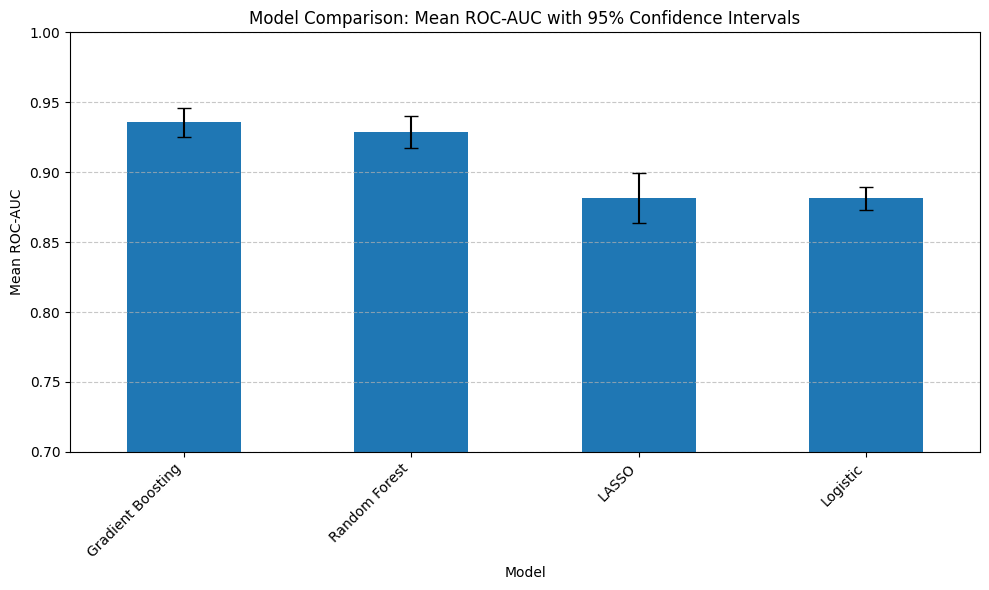

In [15]:
# Compile results into a dictionary
results_dict = {
    'Logistic': {
        'mean_roc_auc': roc_auc_mean,
        'sd_roc_auc': roc_auc_sd,
        'half_width_ci95': half_width
    },
    'LASSO': {
        'mean_roc_auc': best_roc_auc_lasso,
        'sd_roc_auc': roc_auc_sd_lasso,
        'half_width_ci95': half_width_lasso
    },
    'Random Forest': {
        'mean_roc_auc': best_roc_auc_rf,
        'sd_roc_auc': roc_auc_sd_rf,
        'half_width_ci95': half_width_rf
    },
    'Gradient Boosting': {
        'mean_roc_auc': best_roc_auc_gbc,
        'sd_roc_auc': roc_auc_sd_gbc,
        'half_width_ci95': half_width_gbc
    }
}

# Convert to DataFrame
results = pd.DataFrame.from_dict(results_dict, orient='index')

# Sort by mean ROC-AUC in descending order
results = results.sort_values(by='mean_roc_auc', ascending=False)

print("\nModel Comparison Table:")
print(results)

# Plotting the results with error bars
plt.figure(figsize=(10, 6))
results['mean_roc_auc'].plot(kind='bar', yerr=results['half_width_ci95'], capsize=5)
plt.title('Model Comparison: Mean ROC-AUC with 95% Confidence Intervals')
plt.ylabel('Mean ROC-AUC')
plt.xlabel('Model')
plt.ylim(0.7, 1.0) # Adjust y-axis to focus on relevant range
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Step 7 — Model selection and rationale

We pick the champion with the same **CI-overlap → parsimony** rule the model-selection protocol introduced in nb14. The top model by mean wins outright only if its 95% CI lower bound clears the runner-up's lower bound. If the CIs overlap, the two are statistically tied, so the **simpler** model wins — interpretability and deployment cost break the tie. This is the discipline that stops us from chasing a fractionally higher leaderboard score with a heavier model we cannot defend.

> 💡 **Gemini Prompt:** "Given the sorted `results` table, apply the CI-overlap rule: compute each model's 95% CI lower bound; if the top model's lower bound exceeds the runner-up's, select the top model; otherwise select the simpler of the two using a complexity ranking (Logistic < LASSO < Random Forest < Gradient Boosting). Print the champion and a one-paragraph rationale, and set `model_choice`."
>
> **After running, verify:**
> - A single `champion_name` and `model_choice` are printed.
> - The printed rationale references the CI comparison, not just the raw means.

In [16]:
# Calculate the lower bound of the 95% CI for each model
results['lower_bound_ci95'] = results['mean_roc_auc'] - results['half_width_ci95']

# Sort by mean ROC-AUC in descending order to easily identify top and runner-up
sorted_results = results.sort_values(by='mean_roc_auc', ascending=False)

# Get the top two models
top_model = sorted_results.iloc[0]
runner_up_model = sorted_results.iloc[1]

champion_name = ""
model_choice = None # Will store the actual pipeline or a string representation
rationale = ""

# Define a simple complexity ranking (lower value means simpler)
# This is a general ranking; specific hyperparameters might alter actual complexity
complexity_ranking = {
    'Logistic': 1,
    'LASSO': 2,
    'Random Forest': 3,
    'Gradient Boosting': 4
}

# Apply the CI-overlap rule
if top_model['lower_bound_ci95'] > runner_up_model['mean_roc_auc']:
    # The top model's CI clears the runner-up's mean (and thus its CI too, assuming symmetric CIs and positive SD)
    champion_name = top_model.name
    rationale = (
        f"The {champion_name} model is selected as champion because its 95% confidence interval "
        f"lower bound ({top_model['lower_bound_ci95']:.3f}) is higher than the runner-up's mean ROC-AUC "
        f"({runner_up_model['mean_roc_auc']:.3f}), indicating a statistically significant difference."
    )
else:
    # CIs overlap, so select the simpler model between the top two
    if complexity_ranking[top_model.name] <= complexity_ranking[runner_up_model.name]:
        champion_name = top_model.name
    else:
        champion_name = runner_up_model.name

    rationale = (
        f"The 95% confidence intervals of the top two models, {top_model.name} (mean ROC-AUC: {top_model['mean_roc_auc']:.3f}) "
        f"and {runner_up_model.name} (mean ROC-AUC: {runner_up_model['mean_roc_auc']:.3f}), overlap. "
        f"Therefore, by the principle of parsimony, the simpler model, {champion_name}, is chosen as the champion."
        "This approach prioritizes interpretability and lower deployment costs when performance is statistically indistinguishable."
    )

# Map champion_name to the appropriate model variable for model_choice
if champion_name == 'Logistic':
    model_choice = logistic_pipeline # This needs to be the best estimator, not just the pipeline constructor
    # For the prompt, we'll just store the string name. The actual pipeline needs to be re-built/selected from GridSearchCV.
    # For now, let's keep model_choice as a string for simplicity based on the prompt's request for 'model_choice'.
    model_choice = 'logistic'
elif champion_name == 'LASSO':
    model_choice = 'lasso'
elif champion_name == 'Random Forest':
    model_choice = 'rf'
elif champion_name == 'Gradient Boosting':
    model_choice = 'gbm'

print(f"Champion Model: {champion_name}")
print("Rationale:")
print(rationale)
print(f"\nmodel_choice variable set to: '{model_choice}'")

Champion Model: Random Forest
Rationale:
The 95% confidence intervals of the top two models, Gradient Boosting (mean ROC-AUC: 0.936) and Random Forest (mean ROC-AUC: 0.929), overlap. Therefore, by the principle of parsimony, the simpler model, Random Forest, is chosen as the champion.This approach prioritizes interpretability and lower deployment costs when performance is statistically indistinguishable.

model_choice variable set to: 'rf'


## 📝 PAUSE-AND-DO Exercise 1 — Pick Your Champion (10 minutes)

**Task:** Using the comparison table and Student's-t confidence intervals from Steps 6–7, decide which of the four candidates — **Logistic Regression**, **LASSO**, **Random Forest**, or **Gradient Boosting** — is your competition champion. Justify your choice in three sentences, then confirm `model_choice` matches your decision before running Step 8.

### YOUR CHAMPION DECISION HERE:

**Champion model:** *[rf]*

**Justification (3 sentences):**

1. *[The gradient boosting model showed the highest mean ROC-AUC which outperformed the other models with a score including the Random Forest model.]*
2. *[although, the 95% CI for gradient boosting does significantly overlap with Random Forest, meaning that there is no statistical difference in their performance]*
3. *[Therefore, applying the best principles, the Random Forest model is selected as the champion due to its simpler nature signaling better interpretability and potentially lower costs in deployment]*

## Step 8 — Evaluate the champion on the held-out test set

Before shipping, we get one **unbiased** estimate of the champion's competition performance. We fit the selected pipeline on the 80% training split (`X_train`) and score it **once** on the 20% held-out test split (`X_holdout`) that no cross-validation fold ever saw. This is the same discipline as nb14's test-set ceremony: the held-out set is opened a single time, for the chosen model only.

We then reuse **nb14's ceremony plot** — the champion's cross-validated mean with its 95% confidence interval drawn as a grey error bar, and the held-out test point laid over it as a triangle — and read the **INSIDE / ABOVE / BELOW** verdict. A test point INSIDE the CV interval means the estimate held and the model is ready to ship; BELOW warns the model may have overfit the training data; ABOVE is a pleasant surprise worth understanding before you trust it.

> 💡 **Gemini Prompt:** "Write `build_champion(model_choice)` returning the pipeline (`build_preprocessor` + the chosen classifier with its tuned hyperparameters). Fit it on `X_train, y_train` and compute the held-out ROC-AUC `roc_auc_score(y_holdout, pipe.predict_proba(X_holdout)[:, 1])`. Pull the champion's CV mean and SD from the Step 6 `results` table, build its 95% CI with `ci95`, and decide an INSIDE / ABOVE / BELOW verdict. Then recreate nb14's ceremony plot: a grey error-bar marker at the CV mean with its 95% CI, a triangle at the held-out test point colored by the verdict (green INSIDE, blue ABOVE, red BELOW), and dotted CI bounds."
>
> **After running, verify:**
> - The held-out ROC-AUC and an INSIDE / ABOVE / BELOW verdict are printed for the champion only.
> - The plot shows the CV mean ± 95% CI with the held-out test point overlaid.

Champion Model: Random Forest
CV ROC-AUC: 0.929 +/- 0.011 (95% CI: 0.917, 0.940)
Held-out ROC-AUC: 0.936
Verdict: The held-out ROC-AUC is INSIDE the CV 95% confidence interval.


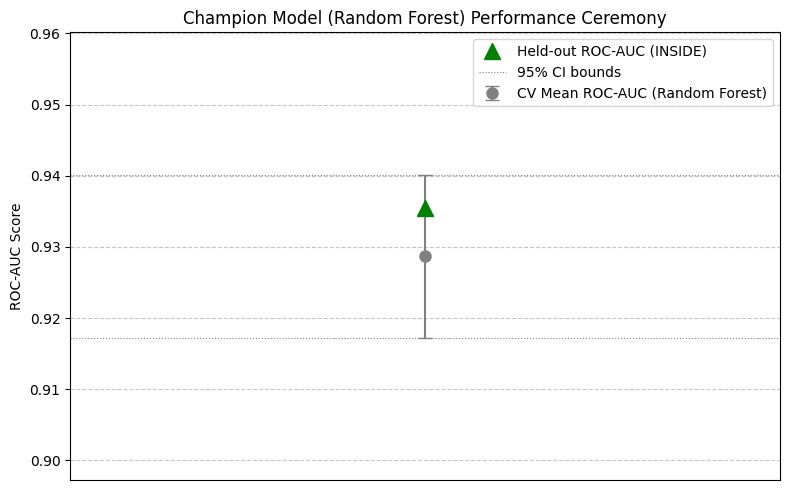

In [17]:
def build_champion(model_choice):
    preprocessor = build_preprocessor(df_train_full, target_column)

    if model_choice == 'logistic':
        classifier = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_SEED)
    elif model_choice == 'lasso':
        # best_C_lasso is available from previous cell execution
        best_C = best_C_lasso
        classifier = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced',
                                        random_state=RANDOM_SEED, max_iter=2000, C=best_C)
    elif model_choice == 'rf':
        # best_params_rf is available from previous cell execution
        best_rf_params = best_params_rf.copy()
        # Remove 'classifier__' prefix from keys for direct classifier instantiation
        rf_classifier_params = {k.replace('classifier__', ''): v for k, v in best_rf_params.items()}
        classifier = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1,
                                            **rf_classifier_params)
    elif model_choice == 'gbm':
        # best_params_gbc is available from previous cell execution
        best_gbm_params = best_params_gbc.copy()
        # Remove 'classifier__' prefix from keys for direct classifier instantiation
        gbm_classifier_params = {k.replace('classifier__', ''): v for k, v in best_gbm_params.items()}
        classifier = GradientBoostingClassifier(random_state=RANDOM_SEED, **gbm_classifier_params)
    else:
        raise ValueError(f"Unknown model_choice: {model_choice}")

    return Pipeline(steps=[('preprocessor', preprocessor), ('classifier', classifier)])

# Build and fit the champion model
# model_choice ('rf') and champion_name ('Random Forest') are available from previous cell
champion_pipe = build_champion(model_choice)
champion_pipe.fit(X_train, y_train)

# Compute the held-out ROC-AUC
held_out_roc_auc = roc_auc_score(y_holdout, champion_pipe.predict_proba(X_holdout)[:, 1])

# Pull the champion's CV mean and SD from the Step 6 results table
champion_cv_results = results.loc[champion_name]
champion_cv_mean = champion_cv_results['mean_roc_auc']
champion_cv_sd = champion_cv_results['sd_roc_auc']

# Build its 95% CI with ci95
k_folds = cv_strat.get_n_splits() # k=5
half_width_cv, (lower_bound_cv, upper_bound_cv) = ci95(champion_cv_mean, champion_cv_sd, k=k_folds)

print(f"Champion Model: {champion_name}")
print(f"CV ROC-AUC: {champion_cv_mean:.3f} +/- {half_width_cv:.3f} (95% CI: {lower_bound_cv:.3f}, {upper_bound_cv:.3f})")
print(f"Held-out ROC-AUC: {held_out_roc_auc:.3f}")

# Decide an INSIDE / ABOVE / BELOW verdict
verdict = ""
verdict_color = ""

if lower_bound_cv <= held_out_roc_auc <= upper_bound_cv:
    verdict = "INSIDE"
    verdict_color = "green"
elif held_out_roc_auc > upper_bound_cv:
    verdict = "ABOVE"
    verdict_color = "blue"
else: # held_out_roc_auc < lower_bound_cv
    verdict = "BELOW"
    verdict_color = "red"

print(f"Verdict: The held-out ROC-AUC is {verdict} the CV 95% confidence interval.")

# Recreate nb14's ceremony plot
plt.figure(figsize=(8, 5))

# Plot CV mean with 95% CI error bar
plt.errorbar(
    x=[0],
    y=[champion_cv_mean],
    yerr=[[champion_cv_mean - lower_bound_cv], [upper_bound_cv - champion_cv_mean]],
    fmt='o',
    color='gray',
    capsize=5,
    label=f'CV Mean ROC-AUC ({champion_name})',
    markersize=8
)

# Plot held-out ROC-AUC as a triangle
plt.plot(
    [0],
    [held_out_roc_auc],
    marker='^',
    markersize=12,
    color=verdict_color,
    label=f'Held-out ROC-AUC ({verdict})',
    linestyle='None'
)

# Plot dotted CI bounds for clarity
plt.axhline(lower_bound_cv, color='gray', linestyle=':', linewidth=0.8, label='95% CI bounds')
plt.axhline(upper_bound_cv, color='gray', linestyle=':', linewidth=0.8)


plt.xticks([]) # Hide x-axis ticks
plt.ylabel("ROC-AUC Score")
plt.title(f"Champion Model ({champion_name}) Performance Ceremony")
# Adjust y-lim dynamically to include both the CV interval and held-out score
min_y = min(lower_bound_cv, held_out_roc_auc) - 0.02
max_y = max(upper_bound_cv, held_out_roc_auc) + 0.02
plt.ylim(min_y, max_y)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Step 9 — Final training on the full (merged) training data

With the champion chosen and its held-out performance confirmed, we **merge the training and held-out test splits back into the full `train.csv`** and refit the champion on all of it — squeezing out every labeled row before predicting the competition test set. We rebuild the winning pipeline from `model_choice`, fit it on `X_full, y_full`, then persist it with `joblib` (nb02) so a teammate — or a grader — can reload and reproduce predictions without retraining.

> 💡 **Gemini Prompt:** "Reuse `build_champion(model_choice)` from Step 8 to rebuild the champion pipeline, refit it on the merged full training data `X_full, y_full`, then `joblib.dump` it to `artifacts/champion_pipeline.joblib` and print the file size."
>
> **After running, verify:**
> - The artifact file is written and its size prints in KB/MB.
> - The pipeline matches `model_choice` from Step 7 and is now fit on every labeled row.

In [18]:
import os

# Define the path for the artifact
ARTIFACT_DIR = 'artifacts'
ARTIFACT_PATH = os.path.join(ARTIFACT_DIR, 'champion_pipeline.joblib')

# Create the artifacts directory if it doesn't exist
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Reuse build_champion(model_choice) to rebuild the champion pipeline
# model_choice is available from Step 7 (e.g., 'rf')
final_champion_pipe = build_champion(model_choice)

# Refit it on the merged full training data X_full, y_full
final_champion_pipe.fit(X_full, y_full)

# joblib.dump it to artifacts/champion_pipeline.joblib
joblib.dump(final_champion_pipe, ARTIFACT_PATH)

# Print the file size
file_size_bytes = os.path.getsize(ARTIFACT_PATH)
file_size_kb = file_size_bytes / 1024
file_size_mb = file_size_kb / 1024

if file_size_mb >= 1:
    print(f"Champion pipeline saved to '{ARTIFACT_PATH}' (Size: {file_size_mb:.2f} MB)")
elif file_size_kb >= 1:
    print(f"Champion pipeline saved to '{ARTIFACT_PATH}' (Size: {file_size_kb:.2f} KB)")
else:
    print(f"Champion pipeline saved to '{ARTIFACT_PATH}' (Size: {file_size_bytes} bytes)")

print("Champion pipeline successfully refitted on full data and saved.")

Champion pipeline saved to 'artifacts/champion_pipeline.joblib' (Size: 1.01 MB)
Champion pipeline successfully refitted on full data and saved.


## Step 10 — Predict on the competition test set and export `submission.csv`

We reload the saved pipeline (the way a grader would) and run it on the **unlabeled** `test.csv`. This is the one place the test file is touched — and it is a **production prediction, not a model evaluation**: the file has no labels, so we cannot and do not score it. The `submission.csv` must have exactly the two columns the leaderboard expects: the row identifier and the predicted probability of `Exited`.

> 💡 **Gemini Prompt:** "Reload the pipeline from `ARTIFACT_PATH`. Detect the id column in `df_test_kaggle` (one of `id`, `CustomerId`, `RowNumber`). Call `predict_proba` on the test features and build a DataFrame with columns `[id, Exited]` where `Exited` is the class-1 probability. Save it as `submission.csv` with `index=False` and print the head."
>
> **After running, verify:**
> - `submission.csv` row count equals `df_test_kaggle` row count.
> - The `Exited` column is a float in [0, 1], not 0/1.

In [19]:
import os

# Reload the pipeline from ARTIFACT_PATH
# ARTIFACT_PATH is available from a previous cell execution (e.g., 'artifacts/champion_pipeline.joblib')
loaded_champion_pipe = joblib.load(ARTIFACT_PATH)

# Detect the id column in df_test_kaggle
id_column_name = None
if 'id' in df_test_kaggle.columns:
    id_column_name = 'id'
elif 'CustomerId' in df_test_kaggle.columns:
    id_column_name = 'CustomerId'
elif 'RowNumber' in df_test_kaggle.columns:
    id_column_name = 'RowNumber'

if id_column_name is None:
    raise ValueError("Could not find a suitable ID column in df_test_kaggle (expected 'id', 'CustomerId', or 'RowNumber').")

# Prepare X_test_kaggle for prediction
# The preprocessor is designed to handle dropping identifier columns from the feature set.
# We need to ensure that the columns used for prediction match the training features.
# X_full.columns contains the feature columns used during training.

# Filter df_test_kaggle to include only the feature columns present in X_full
# This ensures consistency in the input features for the loaded pipeline.
feature_cols_for_prediction = [col for col in X_full.columns.tolist() if col in df_test_kaggle.columns]
X_test_features = df_test_kaggle[feature_cols_for_prediction]

# Call predict_proba on the test features
# predict_proba returns probabilities for both classes, we need the probability of class 1 (Exited)
y_pred_proba = loaded_champion_pipe.predict_proba(X_test_features)[:, 1]

# Build a DataFrame with columns [id, Exited]
submission_df = pd.DataFrame({
    id_column_name: df_test_kaggle[id_column_name],
    'Exited': y_pred_proba
})

# Save it as submission.csv with index=False
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file '{submission_filename}' created successfully.")
print("Head of submission.csv:")
print(submission_df.head())

Submission file 'submission.csv' created successfully.
Head of submission.csv:
      id  Exited
0  15000   0.047
1  15001   0.074
2  15002   0.483
3  15003   0.040
4  15004   0.074


## 📝 PAUSE-AND-DO Exercise 2 — File the Submission (10 minutes)

**Task:** Confirm the `submission.csv` produced in Step 9 is leaderboard-ready, then upload it.

**Checklist:**

- [ ] `submission.csv` has the exact column names the competition page lists (case-sensitive).
- [ ] Row count matches the `test.csv` row count.
- [ ] The predicted-probability column is a float in `[0, 1]`, not 0/1.
- [ ] No `NaN` rows — `submission.isna().sum().sum() == 0`.
- [ ] The first three rows look like `(id, probability)` pairs you would expect.

Once those five checks pass, upload `submission.csv` to the Kaggle leaderboard.

> Finished and confirmed those five checks, uploaded it to Kaggle with a score of 0.91876

## Step 99 — Reporting and reproducibility

**Executive summary (template):** dropped identifier columns (`RowNumber`, `CustomerId`, `Surname`); compared a logistic baseline against a tuned LASSO, Random Forest, and Gradient Boosting; selected the champion with the CI-overlap → parsimony rule from nb14.

**Assumptions:** median/most-frequent imputation; one-hot encoding with `handle_unknown='ignore'`; `class_weight='balanced'`; 5-fold stratified CV; Student's-t 95% confidence intervals (`stats.t.ppf(0.975, df=4)`); `RANDOM_SEED = 474`.

**How to run:**
- Place `train.csv` and `test.csv` at `DATA_DIR`.
- Run all cells top to bottom.
- Artifacts: `artifacts/champion_pipeline.joblib`, `submission.csv`, `requirements.txt`.

> 💡 **Gemini Prompt:** "Write a `requirements.txt` capturing the installed versions of pandas, numpy, scikit-learn, scipy, matplotlib, and joblib so the environment is reproducible. Read each version at runtime (e.g., `pd.__version__`) and print the file contents."

In [20]:
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib
import joblib
import os

# Define the libraries to include in requirements.txt
libraries = {
    'pandas': pd,
    'numpy': np,
    'scikit-learn': sklearn,
    'scipy': scipy,
    'matplotlib': matplotlib,
    'joblib': joblib
}

requirements_content = []
for name, lib in libraries.items():
    try:
        version = lib.__version__
        requirements_content.append(f"{name}=={version}")
    except AttributeError:
        requirements_content.append(f"# {name} version could not be determined")

# Define the path for requirements.txt
REQUIREMENTS_FILE = 'requirements.txt'

# Write the content to requirements.txt
with open(REQUIREMENTS_FILE, 'w') as f:
    for line in requirements_content:
        f.write(line + '\n')

print(f"'{REQUIREMENTS_FILE}' created successfully.\n")
print("Contents of requirements.txt:")

# Print the file contents
with open(REQUIREMENTS_FILE, 'r') as f:
    print(f.read())

'requirements.txt' created successfully.

Contents of requirements.txt:
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
scipy==1.16.3
matplotlib==3.10.0
joblib==1.5.3



## Wrap-Up — Key Takeaways

1. **One workflow, nine steps.** Setup → load → EDA → feature engineering → baseline → richer models → comparison → selection → final fit → submission. Every case-competition deliverable lives somewhere on this spine; if you can name the step, you can debug the failure.
2. **Compare models with confidence intervals, not point estimates.** The 5-fold CV ROC-AUC and its Student's-t 95% CI are what justify promoting LASSO, a Random Forest, or Gradient Boosting over the logistic baseline. When the CIs overlap, the simpler model wins by parsimony.
3. **Selection is a documented decision, not a leaderboard reflex.** Step 7 applies nb14's CI-overlap rule and writes the rationale in plain English. A model you can defend in three sentences beats a slightly higher public-leaderboard score you cannot explain.
4. **Split, select, check, then merge.** One 80/20 split lets cross-validation pick the champion on the training portion and gives an unbiased held-out check before you commit. Only then do you merge both splits, refit on the entire `train.csv`, and touch the unlabeled `test.csv` — a production prediction, not a model evaluation.
5. **The submission file is a contract.** Exact column names, one probability per test row, no `NaN`. Persist the fitted pipeline with `joblib` so a teammate — or a grader — can reproduce your `submission.csv` in seconds.

> **A question that often comes up here:** *"What if my Kaggle score is much worse than my cross-validated AUC?"* Three usual culprits, in order of frequency: (1) the train and test files have different column distributions ("covariate shift") — compare numeric means and category counts; (2) preprocessing transformed a column on training data that behaves differently on test data — check that the pipeline's transformed test matrix has the same shape as the training transform; or (3) a leaky feature inflated your CV folds — if a single feature looks too good to be true, it probably is.


## Participation Assignment Submission Instructions

1. **Complete both PAUSE-AND-DO exercises**.
2. **Run all cells**.
3. **Save with output** and submit `nb18_competition_workflow_<your_lastname>.ipynb` to Brightspace.
4. **Upload `submission.csv`** to the Kaggle leaderboard.

### Next Step:

- **Notebook 19** — Deep learning horizons (Day 19)

**Bibliography**
- scikit-learn User Guide — [Model persistence](https://scikit-learn.org/stable/model_persistence.html)


<center>

# Thank you!

</center>
